# investalyze — price-segment explorer

Chop selected price series into fixed-width raw windows via `investalyze.analysis.segments`, then
compare ways to **rebase / normalise** each window into a comparable vector
(`investalyze.analysis.encodings`). The encoding is the key modelling choice — it defines what
"two segments are similar" means. Splitting a window into segment + successor for the transition
analysis comes later.

Change `CLASSES` / `TICKERS` / `LENGTH` / `STRIDE` and re-run.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

from helpers import connect_readonly
from investalyze.analysis import encodings, segments

con = connect_readonly()

## Selection

Pick broadly by class (`stocks`, `indices`, `bonds`, `currencies`) and/or finely by ticker.

In [2]:
CLASSES = ['stocks', 'indices']
TICKERS = ['AAPL', 'MSFT', '^DJI', '^NDX']  # set to None for every ticker in the chosen classes

CLASSES = ['indices']
TICKERS = None
LENGTH = 20    # trading rows per window (segment length)
STRIDE = 20    # step between window starts (== LENGTH -> non-overlapping)

series = segments.load_series(con, classes=CLASSES, tickers=TICKERS)
series.groupby(['AssetClass', 'Ticker']).size()

AssetClass  Ticker
indices     ^AEX      11054
            ^AOR      13046
            ^ATH       9779
            ^BEL20     9003
            ^BET       6378
                      ...  
            ^TOP40     7788
            ^TSX      12621
            ^TWSE      7823
            ^UKX      23118
            ^XU100     9110
Length: 62, dtype: int64

## Build raw windows

In [3]:
W, meta = segments.build_segments(series, window_length=LENGTH, stride=STRIDE)
print('W       ', W.shape, '(raw prices)')
print('windows ', len(meta))
meta.head()

W        (31705, 20) (raw prices)
windows  31705


,segment_id,Ticker,AssetClass,start_date,end_date,start_idx
0,0,^AEX,indices,1983-01-03,1983-01-28,0
1,1,^AEX,indices,1983-01-31,1983-02-25,20
2,2,^AEX,indices,1983-02-28,1983-03-25,40
3,3,^AEX,indices,1983-03-28,1983-04-26,60
4,4,^AEX,indices,1983-04-27,1983-05-27,80


## Rebase / normalise — methods compared

`build_segments` returns **raw** prices; each window must be normalised before windows at different
price levels are comparable. Each method below answers "what counts as the same shape?" differently.

| method | formula | keeps | pros | cons |
|---|---|---|---|---|
| **raw** | — | level + scale | true prices | windows at different levels never overlap; useless for similarity |
| **rebase to 100** | `v / v[0] * 100` | shape + **amplitude** | level-invariant; Euclidean distance = same shape *and* same size of move; intuitive % scale | anchored to `v[0]` — a noisy first value tilts the whole window; does not normalise volatility |
| **demean** | `v - mean` | shape + **amplitude** (price units) | removes level without an arbitrary anchor; symmetric | not comparable across price levels (a $500 vs a $5 instrument live on different scales) |
| **z-score** | `(v - mean) / std` | **shape only** | removes level *and* volatility → pure pattern; a 3% wiggle clusters with a 30% rally of the same form | discards amplitude (can't tell a big move from a small one); unstable for near-flat windows (std → 0) |
| **min-max** | `(v - min) / (max - min)` | shape, bounded [0,1] | bounded range, easy to read | dominated by extremes — one spike squashes the rest; amplitude lost |

`log_returns(v)` is a different *representation* (per-step returns, length `m-1`): additive and
symmetric up/down, better for statistical/Markov modelling than for overlaying shapes.

**For motif clustering, amplitude usually matters → rebase-to-100 (or demean) + Euclidean.** Use
z-score only when pure shape, ignoring move size, is genuinely what you want to group on.

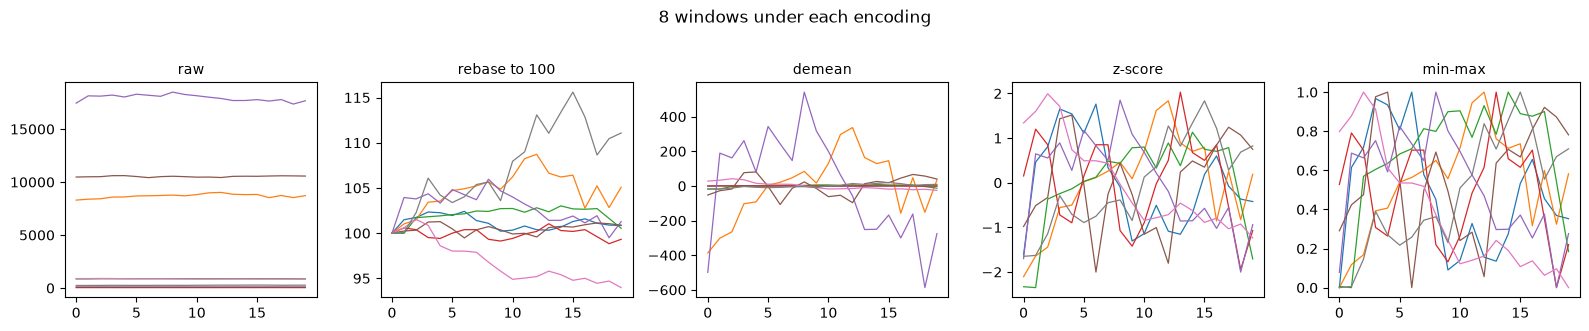

In [4]:
# same sample of windows under each encoding, side by side
methods = {
    'raw': lambda M: M,
    'rebase to 100': encodings.rebase_to_100,
    'demean': encodings.demean,
    'z-score': encodings.zscore,
    'min-max': encodings.minmax,
}

rng = np.random.default_rng(0)
sample = W[rng.choice(len(W), size=min(8, len(W)), replace=False)]

fig, axes = plt.subplots(1, len(methods), figsize=(3.2 * len(methods), 3.2))
for ax, (name, fn) in zip(axes, methods.items()):
    for row in fn(sample):
        ax.plot(row, lw=0.9)
    ax.set_title(name, fontsize=10)
fig.suptitle(f'{len(sample)} windows under each encoding', y=1.02)
plt.tight_layout()
plt.show()